##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]

---

## 0. Iteration setup

**Import libraries**

In [48]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd

**Load and merge datasets**

In [49]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
df_it1 = pd.read_csv("ships_inventory_iter1.csv")
df_it2 = pd.read_csv("ship_inspections_iter2.csv")

# Merge them together based on the Ship_ID.
df = pd.merge(df_it1, df_it2, on="Ship_ID", how="left")

In [ ]:
df

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In deze sectie analyseren we welke variabelen bruikbaar zijn om `Hull_Integrity` later met handmatige regels te voorspellen.
We focussen op:
- Samenvattende statistieken
- Datakwaliteit (missende waarden + outliers)
- Patronen tussen `Reactor_Power`, `Propulsion_Type`, `Ship_Class` en `Hull_Integrity`

In [89]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Dataset shape:", df.shape)
print("Kolommen:", list(df.columns))

info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Missing": df.isnull().sum().values,
    "Dtype": df.dtypes.values
})
info_df["Missing_%"] = (info_df["Missing"] / len(df) * 100).round(2)
info_df = info_df.sort_values("Missing", ascending=False)

display(info_df)

Dataset shape: (368814, 9)
Kolommen: ['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class']


,Column,Non-Null Count,Missing,Dtype,Missing_%
7,Propulsion_Type,312108,56706,str,15.38
6,Reactor_Power,339345,29469,float64,7.99
2,Model_Cycle,361408,7406,float64,2.01
0,Ship_ID,368814,0,int64,0.00
1,Galactic_Credits,368814,0,int64,0.00
4,Sector,368814,0,str,0.00
3,Ship_Manufacturer,368814,0,str,0.00
5,Hull_Integrity,368814,0,str,0.00
8,Ship_Class,368814,0,str,0.00


De output toont dat de dataset 368814 rijen en 9 kolommen bevat.  
De belangrijkste datakwaliteitsissues zitten in:
- `Propulsion_Type` mist ongeveer 15,4% waarden.
- `Reactor_Power` mist ongeveer 8% waarden.
- `Model_Cycle` mist ongeveer 2% waarden.

In [90]:
display(df.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
Ship_ID,368814.0,7.311485e+09,4.381124e+06,7.301583e+09,7.308105e+09,7.312604e+09,7.315245e+09,7.317101e+09
Galactic_Credits,368814.0,1.945354e+04,1.554047e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,361408.0,7.511265e+03,9.078571e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Reactor_Power,339345.0,7.159053e+01,4.464994e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02


De numerieke samenvatting laat de spreiding van onder andere `Galactic_Credits`, `Model_Cycle` en `Reactor_Power` zien.  
Voor deze iteratie is vooral `Reactor_Power` belangrijk: de spreiding en extreme waarden suggereren dat deze variabele een sterke kandidaat is voor beslisregels in het handmatige classificatiemodel.

In [91]:
display(df.describe(include=["object"]).T)

C:\Users\icanc\AppData\Local\Temp\ipykernel_41516\1308661061.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]).T)


,count,unique,top,freq
Ship_Manufacturer,368814,28,Independent Shipwrights,94444
Sector,368814,51,Calodan Expanse,42150
Hull_Integrity,368814,3,Operational,141464
Propulsion_Type,312108,8,Ion Drive,177607
Ship_Class,368814,8,Shuttle,125887


De categorische output bevestigt dat `Hull_Integrity` de doelvariabele is met drie klassen (`Critical`, `Operational`, `Pristine`).  
Daarnaast tonen `Propulsion_Type` en `Ship_Class` meerdere categorieën die inhoudelijk bruikbaar zijn om klassen van elkaar te onderscheiden.

In [92]:
print("Verdeling Hull_Integrity in aantallen:")
print(df["Hull_Integrity"].value_counts(dropna=False))

Verdeling Hull_Integrity in aantallen:
Hull_Integrity
Operational    141464
Critical       118654
Pristine       108696
Name: count, dtype: int64


De aantallen per `Hull_Integrity`-klasse laten zien hoe de data over de drie klassen verdeeld is.  
Deze verdeling is belangrijk voor de evaluatie: als een klasse duidelijk een kleiner aantal bevat, moet later extra aandacht gaan naar de recall van die klasse (niet alleen totale accuracy).

In [102]:
print("Verdeling Hull_Integrity in percentages:")
print((df["Hull_Integrity"].value_counts(normalize=True) * 100).round(2))

Verdeling Hull_Integrity in percentages:
Hull_Integrity
Operational    38.36
Critical       32.17
Pristine       29.47
Name: proportion, dtype: float64


Hier nogmaals de verdeling maar dan in percentages.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

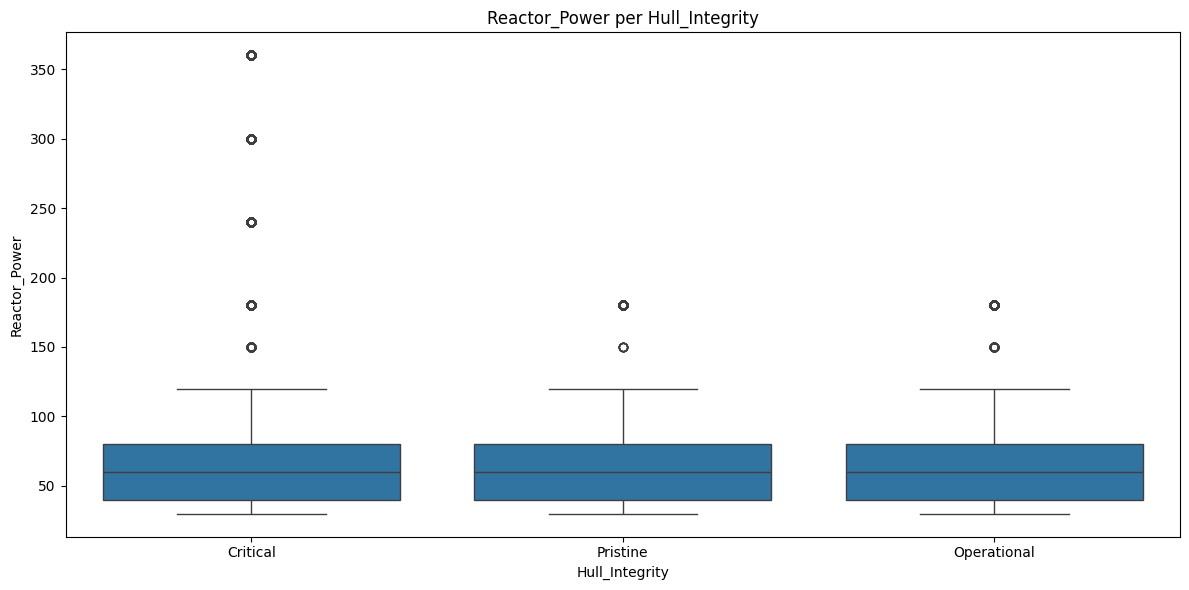

In [124]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
# Reactor_Power vs Hull_Integrity
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Reactor_Power")
plt.title("Reactor_Power per Hull_Integrity")
plt.tight_layout()
plt.show()



De boxplot toont duidelijke overlap tussen de drie klassen, maar ook zichtbare verschillen in uitschieters.
`Critical` bevat duidelijk meer/extremere hoge uitschieters dan de andere klassen.
Dit wijst erop dat hoge `Reactor_Power` waarden een risicosignaal kunnen zijn, maar dat `Reactor_Power` alleen waarschijnlijk niet voldoende is om alle klassen perfect te scheiden.

In [95]:
rp_stats = df.groupby("Hull_Integrity")["Reactor_Power"].agg(["count", "mean", "median"]).round(2)
display(rp_stats)

,count,mean,median
Hull_Integrity,,,
Critical,109248,80.97,60.0
Operational,130134,62.85,60.0
Pristine,99963,72.72,60.0


De tabel bevestigt dat hoewel de mediaan overal gelijk is (60.0), het gemiddelde sterk verschilt. Vooral bij Critical ligt dit gemiddelde veel hoger, wat duidt op een grotere spreiding naar boven toe. Door eerst te splitsen op Reactor_Power en daarna te verfijnen met deze klassen, vangen we die verschillen in verdeling effectief op in de regels voor classificatie.

In [116]:
# Propulsion_Type vs Hull_Integrity (genormaliseerd per Propulsion_Type)
prop_tab = pd.crosstab(df["Propulsion_Type"], df["Hull_Integrity"], normalize="index")
prop_tab_pct = (prop_tab * 100).round(1).astype(str) + '%'
display(prop_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Propulsion_Type,,,
Antimatter,1.7%,0.9%,97.3%
Graviton Beam,2.3%,10.4%,87.3%
Hyperdrive,36.8%,38.2%,25.0%
Ion Drive,32.9%,40.4%,26.7%
Nuclear Pulse,42.8%,46.8%,10.4%
Plasma Hybrid,8.8%,54.1%,37.1%
Plasma Thruster,40.3%,35.6%,24.1%
Solar Sail,25.9%,37.3%,36.7%


De genormaliseerde tabel laat zien dat de verhouding `Critical/Operational/Pristine` sterk verschilt per `Propulsion_Type`.  
Voorbeeld uit de grafiek en tabel: sommige propulsion-types hebben een veel groter aandeel `Pristine`, terwijl andere types meer `Critical/Operational` bevatten.  
Dit maakt `Propulsion_Type` een sterke tweede voorwaarde in if-regels voor de classificatie.

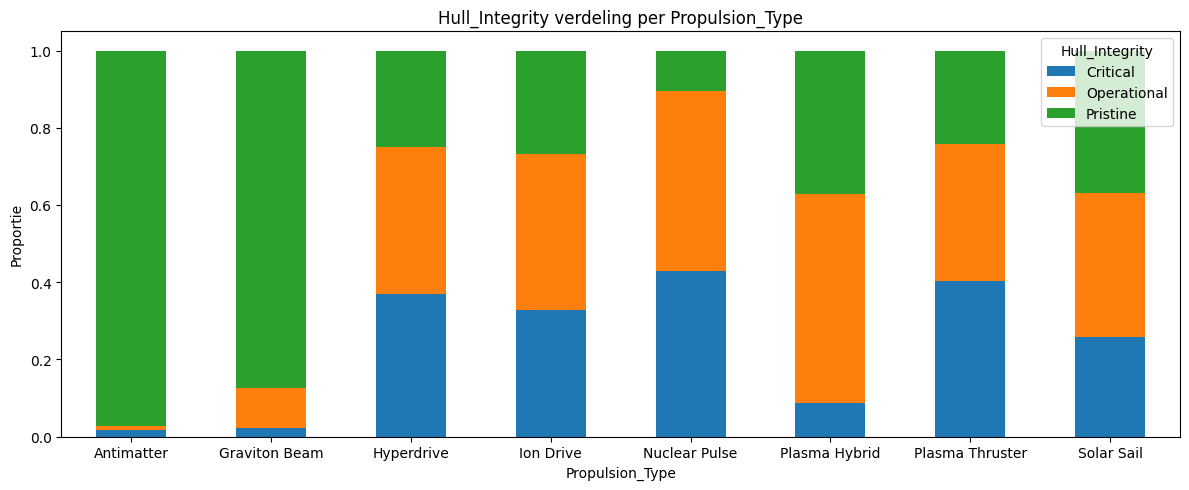

In [123]:
prop_tab.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Hull_Integrity verdeling per Propulsion_Type")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De stacked bar chart bevestigt duidelijke patroonverschillen per propulsion-type:
- `Antimatter` en `Graviton Beam` zijn vooral `Pristine`
- `Nuclear Pulse` en `Plasma Thruster` hebben relatief veel `Critical`
- De rest heeft een relatief gelijkere verdeling.

`antimatter` en `Graviton beam` kunnen we dus gebruiken voor de classificatie regels.

In [119]:
# Ship_Class vs Hull_Integrity (genormaliseerd per Ship_Class)
class_tab = pd.crosstab(df["Ship_Class"], df["Hull_Integrity"], normalize="index")
class_tab_pct = (class_tab * 100).round(1).astype(str) + '%'
display(class_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Ship_Class,,,
Corvette,27.1%,42.4%,30.5%
Explorer,29.8%,39.2%,31.0%
Fighter,33.8%,30.6%,35.6%
Freighter,36.8%,34.4%,28.9%
Hauler,26.2%,31.7%,42.1%
Shuttle,36.5%,39.9%,23.7%
Speedster,47.4%,30.2%,22.4%
Troop Transport,30.4%,40.4%,29.2%


De verdeling per Ship_Class is grotendeels vergelijkbaar tussen de drie Hull_Integrity-klassen.
Daarom gebruiken we Ship_Class niet als regel voor de classificatie.

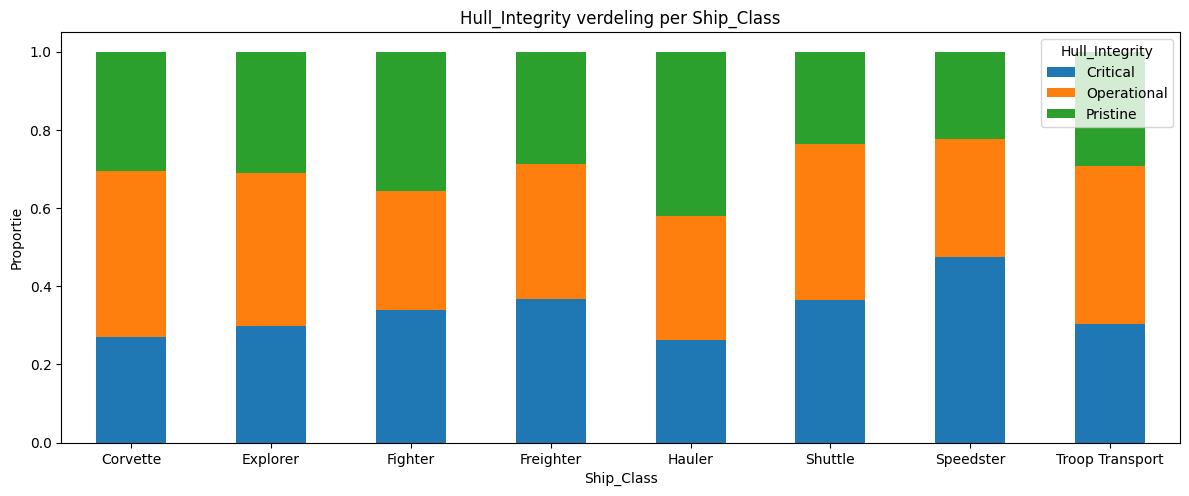

In [126]:
class_tab.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Hull_Integrity verdeling per Ship_Class")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De visualisatie toont dat de verdelingen per Ship_Class over het algemeen vrij vergelijkbaar zijn.  
Er zijn kleine verschillen (zoals een hoger aandeel Critical bij Speedster en een hoger aandeel Pristine bij Hauler), maar de klassen worden niet sterk van elkaar gescheiden op basis van Ship_Class alleen.

Conclusie:
Ship_Class gebruiken we niet als classificatieregel.

In [131]:
rp = df["Reactor_Power"].dropna()

range_quantiles = pd.DataFrame({
    "Metric": ["Minimum", "Q1 (25%)", "Mediaan (50%)", "Q3 (75%)", "Maximum"],
    "Waarde": [
        rp.min(),
        rp.quantile(0.25),
        rp.median(),
        rp.quantile(0.75),
        rp.max()
    ]
})

range_quantiles["Waarde"] = range_quantiles["Waarde"].round(2)
display(range_quantiles)

,Metric,Waarde
0,Minimum,30.0
1,Q1 (25%),40.0
2,Mediaan (50%),60.0
3,Q3 (75%),80.0
4,Maximum,360.0


In deze tabel tonen we de spreiding van Reactor_Power met de minimum- en maximumwaarde en de belangrijkste quantiles (Q1, mediaan, Q3).  
Hiermee maken we expliciet hoe breed de verdeling is en of de hoogste waarden sterk afwijken van het grootste deel van de data.

Deze output gebruiken we als onderbouwing voor de outlier-analyse (IQR) in de volgende cel.

In [100]:
# Outlier-check voor Reactor_Power met IQR
rp = df["Reactor_Power"].dropna()
q1 = rp.quantile(0.25)
q3 = rp.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["Reactor_Power"] < lower) | (df["Reactor_Power"] > upper)]

print("IQR lower bound:", round(lower, 2))
print("IQR upper bound:", round(upper, 2))
print("Aantal mogelijke outliers:", len(outliers))
print("Percentage mogelijke outliers:", round(len(outliers) / len(df) * 100, 2), "%")

IQR lower bound: -20.0
IQR upper bound: 140.0
Aantal mogelijke outliers: 20612
Percentage mogelijke outliers: 5.59 %


De IQR-analyse geeft een onder- en bovengrens voor normale waarden van `Reactor_Power` en toont hoeveel observaties daarbuiten vallen.  
Deze observaties labelen we als mogelijke outliers, maar we verwijderen ze in deze fase niet automatisch.

**Data insights**  
*Samenvatting*  
Uit de analyse blijkt dat `Reactor_Power` en `Propulsion_Type` de meest bruikbare variabelen zijn voor classificatie van `Hull_Integrity`, omdat er een duidelijk verband zit tussen de de Hull_Integrity en de Reactor power en het propulsion type. Daarentegen zien we geen sterk verband terug tussen het `Ship_Class` en de Hull_Integrity, daarom gebruiken `Ship_Class` niet voor de classificatieregels.


Belangrijkste inzichten:
- `Reactor_Power` toont klasseverschillen en duidelijke extreme waarden
- `Propulsion_Type` geeft sterke verschillen in klasseverdeling
- `Ship_Class` gebruiken we NIET voor de classificatie.
- Datakwaliteit vraagt aandacht: missende waarden in `Propulsion_Type` en `Reactor_Power`, plus aanwezige outliers

Beslissing voor volgende stap:
In Modeling gebruiken we een handmatige classifier met `Reactor_Power` als kernregel, verfijnd met `Propulsion_Type`.

**Data quality**

In [134]:
total_duplicates = df.duplicated().sum()
shipid_duplicates = df.duplicated(subset=["Ship_ID"]).sum()

print("Duplicaten (volledige rij):", total_duplicates)
print("Duplicaten op Ship_ID:", shipid_duplicates)

Duplicaten (volledige rij): 500
Duplicaten op Ship_ID: 500


In [156]:
cat_cols = ["Ship_Manufacturer"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Unieke waarden:", df[col].nunique(dropna=True))
    
    # Alle manufacturers
    manufacturer_count = df[col].value_counts(dropna=False)
    print(manufacturer_count)


--- Ship_Manufacturer ---
Unieke waarden: 28
Ship_Manufacturer
Independent Shipwrights        94444
Galactic Motors                57488
Corellian Engineering          44598
Kuat Drive Yards               27843
Hondo Systems                  19394
Jumpship Corp                  16803
Republic Aerospace             16191
General Mining Corp            15233
Nebula Industries              15125
Bayerische Motoren Wormhole    13327
Droid Works                    11685
Mercurian Benz                 10081
Independent                     3524
Ind. Shipwrights                3493
Independent Shipwright          3476
Corellian Engineering Corp      1656
Corelian Engineering            1650
Corellian Eng.                  1647
Galactic_Motors                 1636
Galactic Motrs                  1600
GALACTIC MOTORS                 1592
Galactic Motors                 1555
Kuat Drive                      1034
Kuat DY                         1030
Kuat  Drive Yards               1027
Nebula     

Op basis van de controles zien we het volgende:

- Duplicaten (volledige rij): 500
- Duplicaten op Ship_ID: 500

De duplicaten op volledige rij en op Ship_ID zijn even hoog. Dit wijst erop dat dezelfde records dubbel in de dataset staan. In Data Preparation verwijderen we deze dubbele records om vertekening in de analyse en modellering te voorkomen.

Typos en inconsistente labels:
Bij Ship_Manufacturer zien we duidelijke varianten die inhoudelijk waarschijnlijk hetzelfde betekenen, bijvoorbeeld:
- Independent Shipwrights
- Independent
- Ind. Shipwrights
- Independent Shipwright

Het gaat hier simpelweg om verschillende schrijfwijzen voor dezelfde groepen, niet om unieke nieuwe klassen. Bij het opschonen van de data trekken we deze labels gelijk naar één vaste, uniforme naam.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [ ]:
# CODE CELL: Data cleaning, preprocessing

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [ ]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [ ]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |